In [1]:
!apt-get install ffmpeg -qq
!pip install torchcodec transformers datasets accelerate evaluate scikit-learn pandas matplotlib seaborn wandb soundfile librosa fvcore moviepy torchaudio gdown faster-whisper -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 56.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 53.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 86.0 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import random
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset
from moviepy.video.io.VideoFileClip import VideoFileClip
from transformers import AutoTokenizer, AutoModel, Wav2Vec2FeatureExtractor
from sklearn.model_selection import train_test_split
import gdown
import warnings
import evaluate
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)


In [3]:
# DRAFT CELL

USE_WHISPER_TEXT = False 

csv_url = "https://raw.githubusercontent.com/cfiltnlp/MUStARD_Plus_Plus/main/mustard%2B%2B_text.csv"
df = pd.read_csv(csv_url)

df['label'] = df['Sarcasm'].fillna(0).astype(int)

if USE_WHISPER_TEXT:
    df['text'] = df['SENTENCE'].fillna('') 
else:
    df['text'] = df['SENTENCE'].fillna('')
video_base_dir = "mustard_videos"
video_subdir = "final_utterance_videos"
video_dir = os.path.join(video_base_dir, video_subdir)
audio_dir = "mustard_audio_extracted"

os.makedirs(video_dir, exist_ok=True)
os.makedirs(audio_dir, exist_ok=True)

In [4]:
video_dir = "/kaggle/input/datasets/tresjudamen/utterances/final_utterance_videos"
audio_dir = "mustard_audio_extracted"

os.makedirs(audio_dir, exist_ok=True)

video_files = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]

In [5]:
from tqdm import tqdm

class AudioExtractor:
    def __init__(self, video_dir, audio_dir, target_sr=16000):
        self.video_dir = video_dir
        self.audio_dir = audio_dir
        self.target_sr = target_sr

    def run(self):
        video_files = [f for f in os.listdir(self.video_dir) if f.endswith('.mp4')]
        for filename in tqdm(video_files):
            video_path = os.path.join(self.video_dir, filename)
            audio_name = filename.replace('.mp4', '.wav')
            audio_path = os.path.join(self.audio_dir, audio_name)

            if os.path.exists(audio_path):
                continue

            clip = VideoFileClip(video_path)
            if clip.audio is not None:
                clip.audio.write_audiofile(
                    audio_path,
                    fps=self.target_sr,
                    nbytes=2,
                    codec='pcm_s16le',
                    verbose=False,
                    logger=None
                )
            clip.close()

extractor = AudioExtractor(video_dir, audio_dir)
extractor.run()

100%|██████████| 1203/1203 [04:13<00:00,  4.75it/s]


In [6]:
stats_json_path = "/kaggle/input/datasets/tresjudamen/aamakfa/utterance_asr_stats.json"
with open(stats_json_path, 'r', encoding='utf-8') as f:
    raw_stats = json.load(f)
timestamps_dict = {item['key']: item for item in raw_stats}

if USE_WHISPER_TEXT:
    whisper_dict = {item['key']: item.get('whisper_text', '') for item in raw_stats}
    df['text'] = df['KEY'].map(whisper_dict).fillna(df['text'])

In [7]:
valid_keys = []
for key in df['KEY']:
    audio_path = os.path.join(audio_dir, f"{key}.wav")
    valid_keys.append(os.path.exists(audio_path) and key in timestamps_dict)

df_filtered = df[valid_keys].reset_index(drop=True)

In [8]:
df_train, df_temp = train_test_split(
    df_filtered, test_size=0.3, random_state=SEED, stratify=df_filtered['label']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, random_state=SEED, stratify=df_temp['label']
)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 840, Val: 180, Test: 181


In [10]:
from transformers import WhisperModel

WHISPER_MODEL = "openai/whisper-small"
whisper_encoder = WhisperModel.from_pretrained(WHISPER_MODEL).encoder.to(device)
whisper_encoder.eval()
for p in whisper_encoder.parameters():
    p.requires_grad = False

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [16]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

Финальная версия: обучение на готовых эмбеддингах, полученных из других треков

In [31]:
!pip install thop

In [34]:
import torchaudio
from transformers import WhisperFeatureExtractor, WhisperModel, Wav2Vec2FeatureExtractor, AutoModel
from sklearn.metrics import accuracy_score, f1_score
import time
import gc
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

class MustardAudioDataset(Dataset):
    """custom dataset for audio processing with mono conversion and memory efficiency"""
    
    def __init__(self, data_frame, stats_json, audio_dir, feature_extractor, augment=False):
        """initialize and load essential timestamps only"""
        self.df = data_frame
        self.audio_dir = audio_dir
        self.feature_extractor = feature_extractor
        self.augment = augment
        self.target_sr = 16000

        with open(stats_json, 'r', encoding='utf-8') as f:
            full_stats = json.load(f)

        self.timestamps = {
            item['key']: {
                'start': item['start_of_speech'],
                'end': item['end_of_speech']
            } for item in full_stats if 'start_of_speech' in item and 'end_of_speech' in item
        }

        del full_stats
        gc.collect()

    def __len__(self):
        return len(self.df)

    def apply_augmentations(self, waveform):
        """apply audio augmentations"""
        pitch_factor = random.uniform(-2.0, 2.0)
        waveform = torchaudio.transforms.PitchShift(self.target_sr, pitch_factor)(waveform)
        
        stretch_factor = random.uniform(0.8, 1.2)
        new_freq = int(self.target_sr * stretch_factor)
        resample_up = torchaudio.transforms.Resample(self.target_sr, new_freq)
        resample_down = torchaudio.transforms.Resample(new_freq, self.target_sr)
        waveform = resample_down(resample_up(waveform))
        return waveform

    def __getitem__(self, idx):
        """load audio slice, convert to mono and extract features"""
        row = self.df.iloc[idx]
        key = row['KEY']
        label = row['label']

        audio_path = os.path.join(self.audio_dir, f"{key}.wav")
        waveform, sample_rate = torchaudio.load(audio_path)

        # convert stereo to mono
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # normalize sampling rate
        if sample_rate != self.target_sr:
            waveform = torchaudio.transforms.Resample(sample_rate, self.target_sr)(waveform)

        # extract boundaries
        ts = self.timestamps.get(key)
        if ts is None:
            start_sample, end_sample = 0, waveform.shape[1]
        else:
            start_sample = int(ts['start'] * self.target_sr)
            end_sample = int(ts['end'] * self.target_sr)

        # crop to speech window
        waveform = waveform[:, start_sample:end_sample]

        # handle empty crop safety
        if waveform.shape[1] < 160: # less than 10ms
            waveform = torch.zeros((1, 16000)) # fallback to 1s silence

        if self.augment:
            waveform = self.apply_augmentations(waveform)

        # extract whisper features (must be mono numpy array)
        features = self.feature_extractor(
            waveform.squeeze(0).detach().cpu().numpy(),
            sampling_rate=self.target_sr,
            return_tensors="pt"
        ).input_features.squeeze(0)

        return {
            "input_features": features,
            "label": torch.tensor(label, dtype=torch.long),
            "key": key
        }


class CachedMustardDataset(Dataset):
    """lightning fast dataset with on-the-fly specaugment for cached tensors"""
    
    def __init__(self, data_frame, feature_dir, *args, augment=False, **kwargs):
        """initialize and ignore unused arguments from raw dataset signature"""
        self.df = data_frame
        self.feature_dir = feature_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def apply_spec_augment(self, mel_spec):
        """apply frequency and time masking to the mel spectrogram"""
        if mel_spec.dim() == 2:
            mel_spec = mel_spec.unsqueeze(0)
            
        freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)
        time_mask = torchaudio.transforms.TimeMasking(time_mask_param=35)

        augmented_mel = freq_mask(mel_spec)
        augmented_mel = time_mask(augmented_mel)
        return augmented_mel.squeeze(0)

    def __getitem__(self, idx):
        """load pre-calculated tensor and apply gpu-based augmentation"""
        row = self.df.iloc[idx]
        key = row['KEY']

        feature_path = os.path.join(self.feature_dir, f"{key}.pt")
        try:
            features = torch.load(feature_path)
        except FileNotFoundError:
            print(f"Warning: Feature file not found: {feature_path}. Using zeros.")
            features = torch.zeros((80, 100))

        if self.augment:
            features = self.apply_spec_augment(features)

        return {
            "input_features": features,
            "label": torch.tensor(row['label'], dtype=torch.long),
            "key": key
        }


class PerformanceProfiler:
    """monitor and calculate computational cost and quality metrics"""
    
    def __init__(self, device):
        """initialize profiler with target device"""
        self.device = device

    def measure_flops(self, model, sample_input):
        """calculate floating point operations per second using thop"""
        try:
            from thop import profile
            model.eval()
            flops, params = profile(model, inputs=(sample_input.to(self.device),), verbose=False)
            return flops, params
        except ImportError:
            print("thop not installed. Skipping FLOPs calculation.")
            return 0, 0

    def measure_latency(self, model, dataloader, runs=100):
        """calculate average inference time per sample in milliseconds"""
        model.eval()
        latencies = []

        # perform warmup
        with torch.no_grad():
            batch = next(iter(dataloader))
            warmup_input = batch["input_features"].to(self.device)
            for _ in range(10):
                _ = model(warmup_input)

        # measurement loop
        with torch.no_grad():
            for i, batch in enumerate(dataloader):
                if i >= runs:
                    break
                inputs = batch["input_features"].to(self.device)

                if self.device == "cuda":
                    torch.cuda.synchronize()

                start_time = time.perf_counter()
                _ = model(inputs)

                if self.device == "cuda":
                    torch.cuda.synchronize()
                end_time = time.perf_counter()

                latencies.append((end_time - start_time) * 1000 / inputs.size(0))

        return np.mean(latencies) if latencies else 0, np.std(latencies) if latencies else 0

    def get_memory_stats(self):
        """return peak vram consumption in megabytes"""
        if self.device == "cuda":
            return torch.cuda.max_memory_allocated() / (1024 * 1024)
        return 0.0

In [199]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import json
import os
import gc
import time
from tqdm import tqdm
import psutil
import GPUtil

# Аудио эмбеддинги (словари)
audio_wavlm = np.load('/kaggle/input/datasets/tresjudamen/new-embeddings/audio_embeddings_wavlm_full.npy', allow_pickle=True).item()
audio_whisper = np.load('/kaggle/input/datasets/tresjudamen/new-embeddings/audio_embeddings_whisper_full.npy', allow_pickle=True).item()
ram_after, gpu_after = get_memory_usage()
print(f"\nAfter loading audio embeddings:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")

print(f"WavLM embeddings: {len(audio_wavlm)} samples")
print(f"Whisper embeddings: {len(audio_whisper)} samples")


After loading audio embeddings:
RAM: Δ = 4.8 MB (Total: 4476.3 MB)
WavLM embeddings: 1201 samples
Whisper embeddings: 1201 samples


In [200]:
CSV_PATH = "https://raw.githubusercontent.com/cfiltnlp/MUStARD_Plus_Plus/main/mustard%2B%2B_text.csv"
df_raw = pd.read_csv(CSV_PATH)

df = df_raw[df_raw["KEY"].str.endswith("_u")].copy()
df["label"] = df["Sarcasm"].astype(int)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print(f"\nTrain: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

# Получаем ключи в правильном порядке
train_keys = train_df['KEY'].tolist()
val_keys = val_df['KEY'].tolist()
test_keys = test_df['KEY'].tolist()


Train: 840 samples
Val: 180 samples
Test: 181 samples


In [202]:
text_train_array = np.load('/kaggle/input/datasets/tresjudamen/new-embeddings/text_train_embeddings.npy', allow_pickle=True)
text_val_array = np.load('/kaggle/input/datasets/tresjudamen/new-embeddings/text_val_embeddings.npy', allow_pickle=True)
text_test_array = np.load('/kaggle/input/datasets/tresjudamen/new-embeddings/text_test_embeddings.npy', allow_pickle=True)
ram_after, gpu_after = get_memory_usage()
print(f"\nAfter loading text embeddings:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")

print(f"\nText train array shape: {text_train_array.shape}")
print(f"Text val array shape: {text_val_array.shape}")
print(f"Text test array shape: {text_test_array.shape}")
print(f"Train keys length: {len(train_keys)}")
print(f"Val keys length: {len(val_keys)}")
print(f"Test keys length: {len(test_keys)}")

# Функция для синхронизации ключей с массивами эмбеддингов
def sync_keys_with_embeddings(keys, embeddings_array, audio_dict):
    """
    Синхронизирует ключи с массивами эмбеддингов,
    оставляя только те ключи, которые есть в audio_dict
    и для которых есть соответствующий эмбеддинг
    """
    valid_keys = []
    valid_embeddings = []
    
    for i, key in enumerate(keys):
        if i < len(embeddings_array) and key in audio_dict:
            valid_keys.append(key)
            valid_embeddings.append(embeddings_array[i])
    
    print(f"  Synced: {len(valid_keys)} keys")
    return valid_keys, np.array(valid_embeddings)

# Синхронизируем
train_keys_synced, text_train_synced = sync_keys_with_embeddings(train_keys, text_train_array, audio_wavlm)
val_keys_synced, text_val_synced = sync_keys_with_embeddings(val_keys, text_val_array, audio_wavlm)
test_keys_synced, text_test_synced = sync_keys_with_embeddings(test_keys, text_test_array, audio_wavlm)

# Создаем словари текстовых эмбеддингов по синхронизированным ключам
text_train = {key: text_train_synced[i] for i, key in enumerate(train_keys_synced)}
text_val = {key: text_val_synced[i] for i, key in enumerate(val_keys_synced)}
text_test = {key: text_test_synced[i] for i, key in enumerate(test_keys_synced)}

print(f"\nText train dict: {len(text_train)} samples")
print(f"Text val dict: {len(text_val)} samples")
print(f"Text test dict: {len(text_test)} samples")

# Обновляем списки ключей
train_keys = train_keys_synced
val_keys = val_keys_synced
test_keys = test_keys_synced

# Проверка
if len(train_keys) > 0:
    sample_key = train_keys[0]
    print(f"\nSample key: {sample_key}")
    print(f"WavLM embedding shape: {audio_wavlm[sample_key].shape}")
    print(f"Whisper embedding shape: {audio_whisper[sample_key].shape}")
    print(f"Text embedding shape: {text_train[sample_key].shape}")


After loading text embeddings:
RAM: Δ = 4.8 MB (Total: 4476.3 MB)

Text train array shape: (839, 768)
Text val array shape: (180, 768)
Text test array shape: (180, 768)
Train keys length: 839
Val keys length: 180
Test keys length: 180
  Synced: 839 keys
  Synced: 180 keys
  Synced: 180 keys

Text train dict: 839 samples
Text val dict: 180 samples
Text test dict: 180 samples

Sample key: 1_S11E10_297_u
WavLM embedding shape: (768,)
Whisper embedding shape: (768,)
Text embedding shape: (768,)


In [194]:
from thop import profile

In [205]:
class EmbeddingDataset(Dataset):
    def __init__(self, audio_dict, text_dict, keys_list, labels_dict, augment=False):
        self.keys = [k for k in keys_list if k in audio_dict and k in text_dict and k in labels_dict]
        self.augment = augment
        
        print(f"  Dataset created with {len(self.keys)} samples")
        
        self.audio_emb = []
        self.text_emb = []
        self.labels = []
        
        for key in self.keys:
            self.audio_emb.append(torch.tensor(audio_dict[key], dtype=torch.float32))
            self.text_emb.append(torch.tensor(text_dict[key], dtype=torch.float32))
            self.labels.append(torch.tensor(labels_dict[key], dtype=torch.long))
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, idx):
        audio = self.audio_emb[idx].clone()
        text = self.text_emb[idx].clone()
      
        return {
            "audio_emb": audio,
            "text_emb": text,
            "label": self.labels[idx],
            "key": self.keys[idx]
        }

def collate_fn_embed(batch):
    return {
        "audio_emb": torch.stack([item["audio_emb"] for item in batch]),
        "text_emb": torch.stack([item["text_emb"] for item in batch]),
        "labels": torch.stack([item["label"] for item in batch]),
        "keys": [item["key"] for item in batch]
    }

# Словари меток
train_labels = {row['KEY']: row['label'] for _, row in train_df.iterrows()}
val_labels = {row['KEY']: row['label'] for _, row in val_df.iterrows()}
test_labels = {row['KEY']: row['label'] for _, row in test_df.iterrows()}

train_ds_wavlm = EmbeddingDataset(audio_wavlm, text_train, train_keys, train_labels, augment=True)
val_ds_wavlm = EmbeddingDataset(audio_wavlm, text_val, val_keys, val_labels, augment=False)
test_ds_wavlm = EmbeddingDataset(audio_wavlm, text_test, test_keys, test_labels, augment=False)

train_ds_whisper = EmbeddingDataset(audio_whisper, text_train, train_keys, train_labels, augment=True)
val_ds_whisper = EmbeddingDataset(audio_whisper, text_val, val_keys, val_labels, augment=False)
test_ds_whisper = EmbeddingDataset(audio_whisper, text_test, test_keys, test_labels, augment=False)

ram_after, gpu_after = get_memory_usage()
print(f"\nAfter creating datasets:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")

  Dataset created with 839 samples
  Dataset created with 180 samples
  Dataset created with 180 samples
  Dataset created with 839 samples
  Dataset created with 180 samples
  Dataset created with 180 samples

After creating datasets:
RAM: Δ = 4.8 MB (Total: 4476.3 MB)


In [204]:
BATCH_SIZE = 8

train_loader_wavlm = DataLoader(train_ds_wavlm, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_embed)
val_loader_wavlm = DataLoader(val_ds_wavlm, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_embed)
test_loader_wavlm = DataLoader(test_ds_wavlm, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_embed)

train_loader_whisper = DataLoader(train_ds_whisper, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_embed)
val_loader_whisper = DataLoader(val_ds_whisper, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_embed)
test_loader_whisper = DataLoader(test_ds_whisper, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_embed)

print(f"WavLM train batches: {len(train_loader_wavlm)}")
print(f"Whisper train batches: {len(train_loader_whisper)}")

WavLM train batches: 105
Whisper train batches: 105


In [150]:
class EarlyFusionModel(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=512, num_labels=2, dropout=0.2):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.audio_proj = nn.Linear(audio_dim, hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), 
            nn.ReLU(), 
            nn.Dropout(dropout), 
            nn.Linear(hidden_dim, num_labels)
        )
    
    def forward(self, text_emb, audio_emb, labels=None):
        t = self.text_proj(text_emb)
        a = self.audio_proj(audio_emb)
        x = torch.cat([t, a], dim=1)
        logits = self.classifier(x)
        
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}

class LateFusionModel(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=256, num_labels=2, dropout=0.2):
        super().__init__()
        self.text_head = nn.Sequential(
            nn.Linear(text_dim, hidden_dim), nn.ReLU(), 
            nn.Dropout(dropout), nn.Linear(hidden_dim, num_labels)
        )
        self.audio_head = nn.Sequential(
            nn.Linear(audio_dim, hidden_dim), nn.ReLU(), 
            nn.Dropout(dropout), nn.Linear(hidden_dim, num_labels)
        )
    
    def forward(self, text_emb, audio_emb, labels=None):
        logits = (self.text_head(text_emb) + self.audio_head(audio_emb)) / 2
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}

class CrossAttentionFusionModel(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=256, num_labels=2, dropout=0.2):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.audio_proj = nn.Linear(audio_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(hidden_dim, 4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_labels)
    
    def forward(self, text_emb, audio_emb, labels=None):
        text = self.text_proj(text_emb).unsqueeze(1)
        audio = self.audio_proj(audio_emb).unsqueeze(1)
        attn_out, _ = self.cross_attn(query=text, key=audio, value=audio)
        logits = self.classifier(self.norm(text + attn_out).squeeze(1))
        
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}

class CrossModalTransformer(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=256, num_labels=2, dropout=0.2):
        super().__init__()
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        self.audio_proj = nn.Linear(audio_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=4, dim_feedforward=512,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim))
        self.classifier = nn.Linear(hidden_dim, num_labels)
    
    def forward(self, text_emb, audio_emb, labels=None):
        batch_size = text_emb.size(0)
        t = self.text_proj(text_emb).unsqueeze(1)
        a = self.audio_proj(audio_emb).unsqueeze(1)
        cls = self.cls_token.expand(batch_size, -1, -1)
        out = self.transformer(torch.cat([cls, t, a], dim=1))
        logits = self.classifier(out[:, 0, :])
        
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}

In [152]:
def train_model(model, train_loader, val_loader, test_loader, name, epochs=30, patience=5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    best_val_f1, counter, best_state = 0.0, 0, None
    best_epoch = 0
    
    print(f"\n{name}")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            optimizer.zero_grad()
            loss = model(
                batch["text_emb"].to(device), 
                batch["audio_emb"].to(device), 
                batch["labels"].to(device)
            )["loss"]
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(
                    batch["text_emb"].to(device), 
                    batch["audio_emb"].to(device), 
                    batch["labels"].to(device)
                )
                preds.extend(torch.argmax(out["logits"], dim=-1).cpu().numpy())
                true.extend(batch["labels"].cpu().numpy())
        
        val_f1 = f1_score(true, preds, average='macro')
        scheduler.step(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  Epoch {epoch+1}: val_f1={val_f1:.4f} ✓ (new best)")
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    # Загружаем лучшую модель перед тестированием
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\n  Loading best model from epoch {best_epoch} (val_f1={best_val_f1:.4f})")
    
    # Test with best model
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Testing'):
            out = model(
                batch["text_emb"].to(device), 
                batch["audio_emb"].to(device)
            )
            preds.extend(torch.argmax(out["logits"], dim=-1).cpu().numpy())
            true.extend(batch["labels"].cpu().numpy())
    
    test_acc = accuracy_score(true, preds)
    test_f1 = f1_score(true, preds, average='macro')
    
    return {"test_acc": test_acc, "test_f1": test_f1, "best_val_f1": best_val_f1, "best_epoch": best_epoch}

In [153]:
all_results = []

experiments = [
    (EarlyFusionModel, {}, train_loader_wavlm, val_loader_wavlm, test_loader_wavlm, "WavLM_EarlyFusion"),
    (LateFusionModel, {}, train_loader_wavlm, val_loader_wavlm, test_loader_wavlm, "WavLM_LateFusion"),
    (CrossAttentionFusionModel, {}, train_loader_wavlm, val_loader_wavlm, test_loader_wavlm, "WavLM_CrossAttn"),
    (CrossModalTransformer, {}, train_loader_wavlm, val_loader_wavlm, test_loader_wavlm, "WavLM_CrossModal"),
    (EarlyFusionModel, {}, train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_EarlyFusion"),
    (LateFusionModel, {}, train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_LateFusion"),
    (CrossAttentionFusionModel, {}, train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_CrossAttn"),
    (CrossModalTransformer, {}, train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_CrossModal"),
]

for ModelClass, kwargs, t_loader, v_loader, te_loader, name in experiments:
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    
    gc.collect()
    if device == "cuda": torch.cuda.empty_cache()
    
    model = ModelClass(**kwargs).to(device)
    res = train_model(model, t_loader, v_loader, te_loader, name)
    
    # Замер производительности
    sample = next(iter(te_loader))
    
    try:
        flops, params = profile(
            model, 
            inputs=(sample["text_emb"][:1].to(device), sample["audio_emb"][:1].to(device)), 
            verbose=False
        )
    except:
        params = sum(p.numel() for p in model.parameters())
        flops = params * 2
    
    model.eval()
    latencies = []
    with torch.no_grad():
        for _ in range(50):
            if device == "cuda": torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(sample["text_emb"][:1].to(device), sample["audio_emb"][:1].to(device))
            if device == "cuda": torch.cuda.synchronize()
            latencies.append((time.perf_counter() - start) * 1000)
    latency = np.mean(latencies)
    
    all_results.append({
        "model_name": name,
        "test_acc": res["test_acc"],
        "test_f1": res["test_f1"],
        "best_val_f1": res["best_val_f1"],
        "params_m": params/1e6,
        "flops_g": flops/1e9,
        "latency_ms": latency,
    })
    
    print(f"  Test F1: {res['test_f1']:.4f}")
    print(f"  Params: {params/1e6:.2f}M, FLOPs: {flops/1e9:.2f}G")
    del model


Training: WavLM_EarlyFusion

WavLM_EarlyFusion


  Epoch 1: val_f1=0.4953 ✓ (new best)


  Epoch 2: val_f1=0.6052 ✓ (new best)


  Early stopping at epoch 7

  Loading best model from epoch 2 (val_f1=0.6052)


Testing: 100%|██████████| 23/23 [00:00<00:00, 1605.94it/s]


...

  Epoch 1: val_f1=0.5737 ✓ (new best)


  Epoch 2: val_f1=0.6103 ✓ (new best)


  Early stopping at epoch 7

  Loading best model from epoch 2 (val_f1=0.6103)


Testing: 100%|██████████| 23/23 [00:00<00:00, 803.22it/s]

  Test F1: 0.5408
  Params: 0.92M, FLOPs: 0.00G


         model_name  test_acc  test_f1  best_val_f1  params_m  flops_g  latency_ms
    WavLM_CrossAttn    0.6278   0.6268       0.6268    0.3948   0.0004      0.6022
   WavLM_CrossModal    0.6056   0.6020       0.6452    0.9221   0.0020      0.8983
Whisper_EarlyFusion    0.5889   0.5887       0.6167    1.3133   0.0013      0.2621
 Whisper_LateFusion    0.5833   0.5827       0.6322    0.3948   0.0004      0.3212
  WavLM_EarlyFusion    0.5722   0.5663       0.6052    1.3133   0.0013      0.2545
  Whisper_CrossAttn    0.5722   0.5651       0.5976    0.3948   0.0004      0.6258
   WavLM_LateFusion    0.5556   0.5542       0.6491    0.3948   0.0004      0.3027
 Whisper_CrossModal    0.5444   0.5408       0.6103    0.9221   0.0020      0.8707


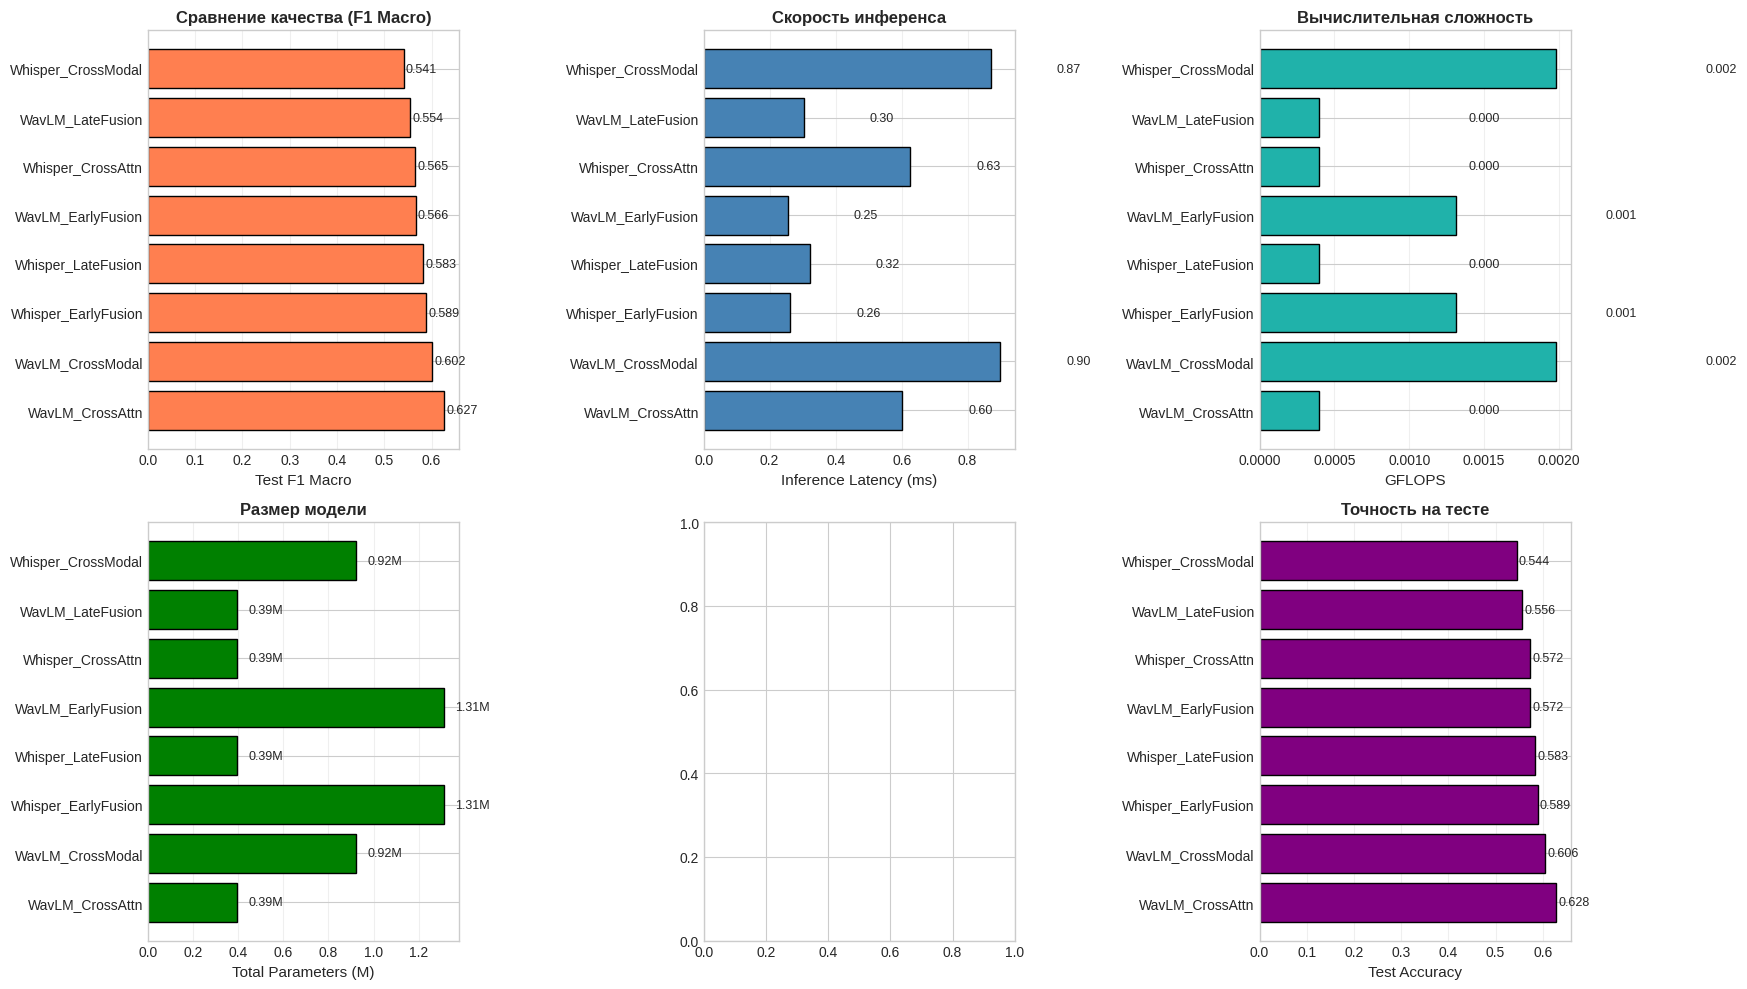

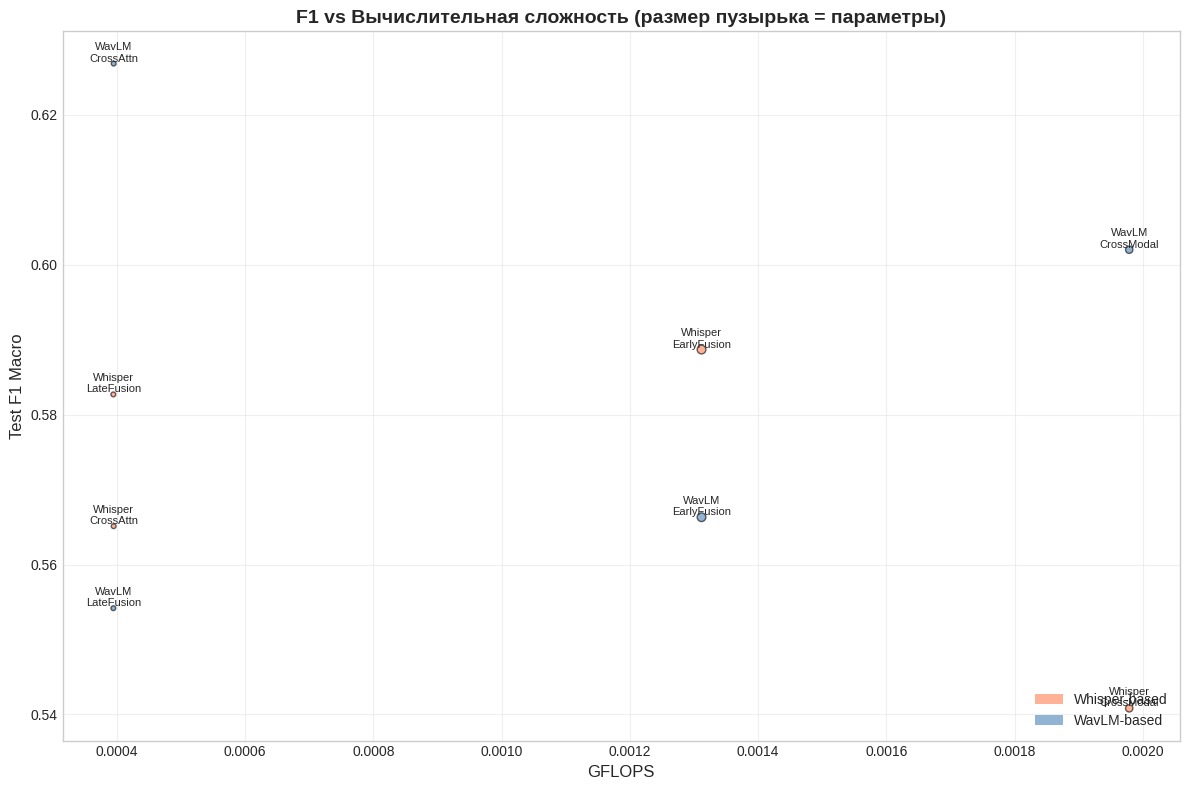

In [155]:
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("test_f1", ascending=False).reset_index(drop=True)

cols = ["model_name", "test_acc", "test_f1", "best_val_f1", "params_m", "flops_g", "latency_ms"]
print(df_results[cols].round(4).to_string(index=False))

df_results.to_csv("pipeline2_embeddings_results.csv", index=False)

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. F1 Score
ax = axes[0, 0]
bars = ax.barh(df_results['model_name'], df_results['test_f1'], color='coral', edgecolor='black')
ax.set_xlabel('Test F1 Macro', fontsize=11)
ax.set_title('Сравнение качества (F1 Macro)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['test_f1']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# 2. Latency
ax = axes[0, 1]
bars = ax.barh(df_results['model_name'], df_results['latency_ms'], color='steelblue', edgecolor='black')
ax.set_xlabel('Inference Latency (ms)', fontsize=11)
ax.set_title('Скорость инференса', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['latency_ms']):
    ax.text(v + 0.2, i, f'{v:.2f}', va='center', fontsize=9)

# 3. GFLOPS
ax = axes[0, 2]
bars = ax.barh(df_results['model_name'], df_results['flops_g'], color='lightseagreen', edgecolor='black')
ax.set_xlabel('GFLOPS', fontsize=11)
ax.set_title('Вычислительная сложность', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['flops_g']):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# 4. Parameters
ax = axes[1, 0]
bars = ax.barh(df_results['model_name'], df_results['params_m'], color='green', edgecolor='black')
ax.set_xlabel('Total Parameters (M)', fontsize=11)
ax.set_title('Размер модели', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['params_m']):
    ax.text(v + 0.05, i, f'{v:.2f}M', va='center', fontsize=9)

# 6. Test Accuracy
ax = axes[1, 2]
bars = ax.barh(df_results['model_name'], df_results['test_acc'], color='purple', edgecolor='black')
ax.set_xlabel('Test Accuracy', fontsize=11)
ax.set_title('Точность на тесте', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['test_acc']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("pipeline2_embeddings_results_detailed.png", dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))

colors = []
for name in df_results['model_name']:
    if 'Whisper' in name:
        colors.append('coral')
    else:
        colors.append('steelblue')

scatter = ax.scatter(df_results['flops_g'], df_results['test_f1'], 
                     s=df_results['params_m']*30,  # размер = параметры
                     c=colors, alpha=0.6, edgecolors='black', linewidth=1)


for i, row in df_results.iterrows():
    ax.annotate(row['model_name'].replace('_', '\n'), 
                (row['flops_g'], row['test_f1']),
                fontsize=8, ha='center', va='bottom')

ax.set_xlabel('GFLOPS', fontsize=12)
ax.set_ylabel('Test F1 Macro', fontsize=12)
ax.set_title('F1 vs Вычислительная сложность (размер пузырька = параметры)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral', alpha=0.6, label='Whisper-based'),
    Patch(facecolor='steelblue', alpha=0.6, label='WavLM-based')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig("pipeline2_embeddings_f1_vs_flops.png", dpi=150, bbox_inches='tight')
plt.show()

Финальная версия: золотые транскрипты из CSV в текстовой части и извлеченные аугментированные данные в аудио-части. Golden + Whisper, Golden + WavLM

In [174]:
!pip install GPUtil psutil

  Preparing metadata (setup.py) ... done
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=5b823c113ae1f1a90ca4c68825f0c251dbc9073c9aed2a53bf20de43fddd6933
  Stored in directory: /root/.cache/pip/wheels/92/a8/b7/d8a067c31a74de9ca252bbe53dea5f896faabd25d55f541037
Successfully built GPUtil


In [175]:
import gc
import time
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import (
    WhisperModel, WhisperProcessor, WhisperFeatureExtractor,
    Wav2Vec2FeatureExtractor, AutoModel, AutoTokenizer,
    Wav2Vec2Model
)
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from thop import profile
import warnings
warnings.filterwarnings('ignore')
import psutil
import GPUtil

In [176]:
def get_memory_usage():
    """Get current RAM and GPU memory usage"""
    ram = psutil.Process().memory_info().rss / 1024**2 
    gpu_mem = 0
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.memory_allocated() / 1024**2 
    return ram, gpu_mem

def print_memory_stage(stage_name, start_ram, start_gpu):
    """Print memory usage for a processing stage"""
    end_ram, end_gpu = get_memory_usage()
    print(f"\n{stage_name}:")
    print(f"   RAM: Δ = {end_ram - start_ram:.1f} MB (Total: {end_ram:.1f} MB)")
    if torch.cuda.is_available():
        print(f"   GPU: Δ = {end_gpu - start_gpu:.1f} MB (Total: {end_gpu:.1f} MB)")

initial_ram, initial_gpu = get_memory_usage()
print(f"Initial memory - RAM: {initial_ram:.1f} MB, GPU: {initial_gpu:.1f} MB")

Initial memory - RAM: 4471.4 MB, GPU: 1391.8 MB


In [177]:
WHISPER_CACHE_DIR = "/kaggle/working/whisper_features_cache"
WAVLM_CACHE_DIR = "/kaggle/working/wavlm_features_cache"
os.makedirs(WHISPER_CACHE_DIR, exist_ok=True)
os.makedirs(WAVLM_CACHE_DIR, exist_ok=True)

def precalculate_whisper_features(df, stats_json, audio_dir, feature_extractor, save_dir):
    """Pre-calculate mel spectrograms for Whisper and save them to disk."""
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    with open(stats_json, 'r') as f:
        timestamps = {item['key']: item for item in json.load(f)}

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Caching Whisper"):
        key = row['KEY']
        save_path = os.path.join(save_dir, f"{key}.pt")
        if os.path.exists(save_path):
            continue

        # Load and convert to mono
        waveform, sr = torchaudio.load(os.path.join(audio_dir, f"{key}.wav"))
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Resample
        if sr != 16000:
            waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

        # Crop using timestamps
        ts = timestamps.get(key)
        if ts:
            start_idx = int(ts['start_of_speech'] * 16000)
            end_idx = int(ts['end_of_speech'] * 16000)
            waveform = waveform[:, start_idx:end_idx]

        # Safety check for empty/too short waveform
        if waveform.shape[1] < 160:
            waveform = torch.zeros((1, 16000))

        # Extract mel features
        mel = feature_extractor(
            waveform.squeeze(0).numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        ).input_features.squeeze(0)

        torch.save(mel.float(), save_path)
    print("Whisper feature caching complete.")


def precalculate_wavlm_features(df, stats_json, audio_dir, extractor, save_dir):
    """Pre-calculate raw input values for WavLM and save them to disk."""
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    with open(stats_json, 'r') as f:
        timestamps = {item['key']: item for item in json.load(f)}

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Caching WavLM"):
        key = row['KEY']
        save_path = os.path.join(save_dir, f"{key}.pt")
        if os.path.exists(save_path):
            continue

        # Load and convert to mono
        waveform, sr = torchaudio.load(os.path.join(audio_dir, f"{key}.wav"))
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # Resample
        if sr != 16000:
            waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)

        # Crop using timestamps
        ts = timestamps.get(key)
        if ts:
            start_idx = int(ts['start_of_speech'] * 16000)
            end_idx = int(ts['end_of_speech'] * 16000)
            waveform = waveform[:, start_idx:end_idx]

        # Safety check
        if waveform.shape[1] < 160:
            waveform = torch.zeros((1, 16000))

        # Extract input_values for WavLM
        inputs = extractor(
            waveform.squeeze(0).numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        ).input_values.squeeze(0)

        torch.save(inputs.float(), save_path)
    print("WavLM feature caching complete.")

In [178]:
# Класс Dataset для загрузки закэшированных фич Whisper
class CachedWhisperDataset(Dataset):
    def __init__(self, data_frame, feature_dir, augment=False):
        self.df = data_frame
        self.feature_dir = feature_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def apply_spec_augment(self, mel_spec):
        if self.augment:
            if mel_spec.dim() == 2:
                mel_spec = mel_spec.unsqueeze(0)
            freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)
            time_mask = torchaudio.transforms.TimeMasking(time_mask_param=35)
            mel_spec = time_mask(freq_mask(mel_spec))
            mel_spec = mel_spec.squeeze(0)
        return mel_spec

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        key = row['KEY']
        path = os.path.join(self.feature_dir, f"{key}.pt")
        try:
            features = torch.load(path).float()
        except FileNotFoundError:
            features = torch.zeros((80, 100), dtype=torch.float32)

        features = self.apply_spec_augment(features)

        return {
            "audio_features": features,
            "label": torch.tensor(row['label'], dtype=torch.long),
            "key": key
        }

# Класс Dataset для загрузки закэшированных фич WavLM (raw waveform)
class CachedWavLMDataset(Dataset):
    def __init__(self, data_frame, feature_dir, augment=False):
        self.df = data_frame
        self.feature_dir = feature_dir
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def apply_audio_augment(self, audio):
        if self.augment and random.random() > 0.5:
            noise = torch.randn_like(audio) * 0.005
            audio = audio + noise
        return audio

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        key = row['KEY']
        path = os.path.join(self.feature_dir, f"{key}.pt")
        try:
            features = torch.load(path).float()
        except FileNotFoundError:
            features = torch.zeros((16000,), dtype=torch.float32)

        features = self.apply_audio_augment(features)

        return {
            "audio_features": features,
            "label": torch.tensor(row['label'], dtype=torch.long),
            "key": key
        }

In [179]:
whisper_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
wavlm_extractor = Wav2Vec2FeatureExtractor.from_pretrained("microsoft/wavlm-base-plus")

precalculate_whisper_features(all_df, STATS_JSON, AUDIO_DIR, whisper_extractor, WHISPER_CACHE_DIR)
start_time = time.time()
precalculate_whisper_features(all_df, STATS_JSON, AUDIO_DIR, whisper_extractor, WHISPER_CACHE_DIR)
whisper_total_time = time.time() - start_time
whisper_per_sample = whisper_total_time / len(all_df) * 1000 
print(f"Whisper preprocessing - Total: {whisper_total_time:.2f}s, Per sample: {whisper_per_sample:.2f}ms")

ram_after, gpu_after = get_memory_usage()
print(f"\nAfter Whisper preprocessing:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")
if torch.cuda.is_available():
    print(f"GPU: Δ = {gpu_after - initial_gpu:.1f} MB (Total: {gpu_after:.1f} MB)")

precalculate_wavlm_features(all_df, STATS_JSON, AUDIO_DIR, wavlm_extractor, WAVLM_CACHE_DIR)
start_time = time.time()
precalculate_wavlm_features(all_df, STATS_JSON, AUDIO_DIR, wavlm_extractor, WAVLM_CACHE_DIR)
wavlm_total_time = time.time() - start_time
wavlm_per_sample = wavlm_total_time / len(all_df) * 1000 
print(f"WavLM preprocessing - Total: {wavlm_total_time:.2f}s, Per sample: {wavlm_per_sample:.2f}ms")

ram_after, gpu_after = get_memory_usage()
print(f"After WavLM preprocessing:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")
if torch.cuda.is_available():
    print(f"GPU: Δ = {gpu_after - initial_gpu:.1f} MB (Total: {gpu_after:.1f} MB)")

Caching Whisper: 100%|██████████| 1201/1201 [00:00<00:00, 22239.90it/s]


Whisper feature caching complete.


Caching Whisper: 100%|██████████| 1201/1201 [00:00<00:00, 21800.52it/s]


Whisper feature caching complete.
Whisper preprocessing - Total: 0.09s, Per sample: 0.07ms

After Whisper preprocessing:
RAM: Δ = 0.0 MB (Total: 4471.4 MB)
GPU: Δ = 0.0 MB (Total: 1391.8 MB)


Caching WavLM: 100%|██████████| 1201/1201 [00:00<00:00, 22145.84it/s]


WavLM feature caching complete.


Caching WavLM: 100%|██████████| 1201/1201 [00:00<00:00, 22654.07it/s]

WavLM feature caching complete.
WavLM preprocessing - Total: 0.09s, Per sample: 0.07ms
After WavLM preprocessing:
RAM: Δ = 0.0 MB (Total: 4471.4 MB)
GPU: Δ = 0.0 MB (Total: 1391.8 MB)


In [180]:
TEXT_MODEL_NAME = "distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
text_encoder = AutoModel.from_pretrained(TEXT_MODEL_NAME).to(device)
text_encoder.eval()
for p in text_encoder.parameters():
    p.requires_grad = False

def get_text_embeddings(data_frame):
    """golden csv transcript"""
    embeddings_dict = {}
    with torch.no_grad():
        for _, row in tqdm(data_frame.iterrows(), total=len(data_frame), desc="Extracting text embeddings"):
            inputs = tokenizer(row['SENTENCE'], return_tensors="pt", padding=True, truncation=True, max_length=128)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            output = text_encoder(**inputs)
            emb = output.last_hidden_state[:, 0, :].cpu().squeeze(0)
            embeddings_dict[row['KEY']] = emb
    return embeddings_dict

total_text_samples = len(train_df) + len(val_df) + len(test_df)

start_time = time.time()

train_text_emb = get_text_embeddings(train_df)
val_text_emb = get_text_embeddings(val_df)
test_text_emb = get_text_embeddings(test_df)

text_total_time = time.time() - start_time
text_per_sample = text_total_time / total_text_samples * 1000
print(f"Text embeddings - Total: {text_total_time:.2f}s, Per sample: {text_per_sample:.2f}ms")

ram_after, gpu_after = get_memory_usage()
print(f"\nAfter text embedding extraction:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")
if torch.cuda.is_available():
    print(f"   GPU: Δ = {gpu_after - initial_gpu:.1f} MB (Total: {gpu_after:.1f} MB)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting text embeddings: 100%|██████████| 181/181 [00:00<00:00, 205.69it/s]

Text embeddings - Total: 5.93s, Per sample: 4.94ms

After text embedding extraction:
RAM: Δ = 5.7 MB (Total: 4477.2 MB)
   GPU: Δ = 0.5 MB (Total: 1392.4 MB)


In [181]:
BATCH_SIZE = 8

def collate_fn_audio_text(batch):
    """Join text and audio"""
    audio_list = [item["audio_features"] for item in batch]
    text_list = [item["text_emb"] for item in batch]
    labels = torch.stack([item["label"] for item in batch])
    keys = [item["key"] for item in batch]

    # Pad audio
    audio_padded = torch.nn.utils.rnn.pad_sequence(audio_list, batch_first=True)
    text_padded = torch.stack(text_list)

    return {
        "audio_features": audio_padded,
        "text_emb": text_padded,
        "labels": labels,
        "keys": keys
    }

# Датасеты для Whisper
train_ds_whisper = CachedWhisperDataset(train_df, WHISPER_CACHE_DIR, augment=True)
val_ds_whisper = CachedWhisperDataset(val_df, WHISPER_CACHE_DIR, augment=False)
test_ds_whisper = CachedWhisperDataset(test_df, WHISPER_CACHE_DIR, augment=False)

# Датасеты для WavLM
train_ds_wavlm = CachedWavLMDataset(train_df, WAVLM_CACHE_DIR, augment=True)
val_ds_wavlm = CachedWavLMDataset(val_df, WAVLM_CACHE_DIR, augment=False)
test_ds_wavlm = CachedWavLMDataset(test_df, WAVLM_CACHE_DIR, augment=False)

# Функция для создания DataLoader'ов для конкретного типа аудио
def get_dataloaders(dataset_obj, text_emb_dict, split_df):
    keys = split_df['KEY'].tolist()
    class WrapperDataset(Dataset):
        def __init__(self, base_ds, text_dict):
            self.base_ds = base_ds
            self.text_dict = text_dict
        def __len__(self):
            return len(self.base_ds)
        def __getitem__(self, idx):
            item = self.base_ds[idx]
            key = item['key']
            item['text_emb'] = self.text_dict[key]
            return item

    wrapped_ds = WrapperDataset(dataset_obj, text_emb_dict)
    return DataLoader(wrapped_ds, batch_size=BATCH_SIZE, shuffle=(split_df is train_df), collate_fn=collate_fn_audio_text)

train_loader_whisper = get_dataloaders(train_ds_whisper, train_text_emb, train_df)
val_loader_whisper = get_dataloaders(val_ds_whisper, val_text_emb, val_df)
test_loader_whisper = get_dataloaders(test_ds_whisper, test_text_emb, test_df)

train_loader_wavlm = get_dataloaders(train_ds_wavlm, train_text_emb, train_df)
val_loader_wavlm = get_dataloaders(val_ds_wavlm, val_text_emb, val_df)
test_loader_wavlm = get_dataloaders(test_ds_wavlm, test_text_emb, test_df)

print(f"Whisper train batches: {len(train_loader_whisper)}")
print(f"WavLM train batches: {len(train_loader_wavlm)}")

Whisper train batches: 105
WavLM train batches: 105


In [182]:
class EarlyFusionModel(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=512, num_labels=2, dropout=0.2, audio_is_mel=False):
        """
        audio_is_mel: True для мел-спектрограмм Whisper,
                     False для готовых эмбеддингов
        """
        super().__init__()
        self.audio_is_mel = audio_is_mel
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        
        # Для мел-спектрограмм [batch, 80, time] -> [batch, hidden]
        if audio_is_mel:
            self.audio_proj = nn.Sequential(
                nn.Conv1d(80, 128, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(128),  # [batch, 128, 128]
                nn.Flatten(),                # [batch, 128*128]
                nn.Linear(128 * 128, hidden_dim)
            )
        else:
            self.audio_proj = nn.Linear(audio_dim, hidden_dim)
            
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), 
            nn.ReLU(), 
            nn.Dropout(dropout), 
            nn.Linear(hidden_dim, num_labels)
        )

    def forward(self, text_emb, audio_features, labels=None):
        t = self.text_proj(text_emb)
  
        if self.audio_is_mel:
            # audio_features: [batch, 80, time] -> [batch, 80, time]
            a = self.audio_proj(audio_features)
        else:
            a = self.audio_proj(audio_features)
            
        x = torch.cat([t, a], dim=1)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {"loss": loss, "logits": logits}


class LateFusionModel(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=256, num_labels=2, dropout=0.2, audio_is_mel=False):
        super().__init__()
        self.audio_is_mel = audio_is_mel
        
        self.text_head = nn.Sequential(
            nn.Linear(text_dim, hidden_dim), nn.ReLU(), 
            nn.Dropout(dropout), nn.Linear(hidden_dim, num_labels)
        )
        
        if audio_is_mel:
            self.audio_proj = nn.Sequential(
                nn.Conv1d(80, 128, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(128),
                nn.Flatten(),
                nn.Linear(128 * 128, hidden_dim)
            )
            self.audio_head = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), 
                nn.Dropout(dropout), nn.Linear(hidden_dim, num_labels)
            )
        else:
            self.audio_head = nn.Sequential(
                nn.Linear(audio_dim, hidden_dim), nn.ReLU(), 
                nn.Dropout(dropout), nn.Linear(hidden_dim, num_labels)
            )

    def forward(self, text_emb, audio_features, labels=None):
        text_logits = self.text_head(text_emb)
        
        if self.audio_is_mel:
            audio_proj = self.audio_proj(audio_features)
            audio_logits = self.audio_head(audio_proj)
        else:
            audio_logits = self.audio_head(audio_features)
            
        logits = (text_logits + audio_logits) / 2
        
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}


class CrossAttentionFusionModel(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=256, num_labels=2, dropout=0.2, audio_is_mel=False):
        super().__init__()
        self.audio_is_mel = audio_is_mel
        
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        
        if audio_is_mel:
            self.audio_pre_proj = nn.Sequential(
                nn.Conv1d(80, 128, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(128),
                nn.Flatten(),
                nn.Linear(128 * 128, hidden_dim)
            )
            self.audio_proj = nn.Identity()  # уже спроецировано
        else:
            self.audio_proj = nn.Linear(audio_dim, hidden_dim)
            
        self.cross_attn = nn.MultiheadAttention(hidden_dim, 4, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, text_emb, audio_features, labels=None):
        text = self.text_proj(text_emb).unsqueeze(1)
        
        if self.audio_is_mel:
            audio_proj = self.audio_pre_proj(audio_features)
            audio = audio_proj.unsqueeze(1)
        else:
            audio = self.audio_proj(audio_features).unsqueeze(1)
            
        attn_out, _ = self.cross_attn(query=text, key=audio, value=audio)
        logits = self.classifier(self.norm(text + attn_out).squeeze(1))

        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}


class CrossModalTransformer(nn.Module):
    def __init__(self, text_dim=768, audio_dim=768, hidden_dim=256, num_labels=2, dropout=0.2, audio_is_mel=False):
        super().__init__()
        self.audio_is_mel = audio_is_mel
        
        self.text_proj = nn.Linear(text_dim, hidden_dim)
        
        if audio_is_mel:
            self.audio_pre_proj = nn.Sequential(
                nn.Conv1d(80, 128, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(128),
                nn.Flatten(),
                nn.Linear(128 * 128, hidden_dim)
            )
            self.audio_proj = nn.Identity()
        else:
            self.audio_proj = nn.Linear(audio_dim, hidden_dim)
            
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=4, dim_feedforward=512,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim))
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, text_emb, audio_features, labels=None):
        batch_size = text_emb.size(0)
        t = self.text_proj(text_emb).unsqueeze(1)
        
        if self.audio_is_mel:
            audio_proj = self.audio_pre_proj(audio_features)
            a = audio_proj.unsqueeze(1)
        else:
            a = self.audio_proj(audio_features).unsqueeze(1)
            
        cls = self.cls_token.expand(batch_size, -1, -1)
        out = self.transformer(torch.cat([cls, t, a], dim=1))
        logits = self.classifier(out[:, 0, :])

        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}

In [183]:
def train_model(model, train_loader, val_loader, test_loader, name, epochs=30, patience=5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    best_val_f1, counter, best_state = 0.0, 0, None
    best_epoch = 0

    print(f"\n{name}")
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            optimizer.zero_grad()
            loss = model(
                batch["text_emb"].to(device),
                batch["audio_features"].to(device),
                batch["labels"].to(device)
            )["loss"]
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        preds, true = [], []
        with torch.no_grad():
            for batch in val_loader:
                out = model(
                    batch["text_emb"].to(device),
                    batch["audio_features"].to(device),
                    batch["labels"].to(device)
                )
                preds.extend(torch.argmax(out["logits"], dim=-1).cpu().numpy())
                true.extend(batch["labels"].cpu().numpy())

        val_f1 = f1_score(true, preds, average='macro')
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  Epoch {epoch+1}: val_f1={val_f1:.4f} ✓ (new best)")
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # Загружаем лучшую модель перед тестированием
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\n  Loading best model from epoch {best_epoch} (val_f1={best_val_f1:.4f})")

    # Test with best model
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Testing'):
            out = model(
                batch["text_emb"].to(device),
                batch["audio_features"].to(device)
            )
            preds.extend(torch.argmax(out["logits"], dim=-1).cpu().numpy())
            true.extend(batch["labels"].cpu().numpy())

    test_acc = accuracy_score(true, preds)
    test_f1 = f1_score(true, preds, average='macro')

    return {"test_acc": test_acc, "test_f1": test_f1, "best_val_f1": best_val_f1, "best_epoch": best_epoch}

In [184]:
def measure_performance_universal(model, sample_batch, device, n_runs=100):
    """latency, memory, GFLOPS"""
    model.eval()
    model.to(device)

    batch = {
        "text_emb": sample_batch["text_emb"][:1].to(device),
        "audio_features": sample_batch["audio_features"][:1].to(device)
    }

    # Прогрев
    for _ in range(10):
        with torch.no_grad():
            _ = model(**batch)

    # End-To-End Latency
    if device == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    for _ in range(n_runs):
        with torch.no_grad():
            _ = model(**batch)

    if device == "cuda":
        torch.cuda.synchronize()
    end_time = time.perf_counter()
    avg_latency_ms = (end_time - start_time) * 1000 / n_runs

    # Peak Memory Usage
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            _ = model(**batch)
        peak_memory_mb = torch.cuda.max_memory_allocated() / 1024**2
    else:
        peak_memory_mb = 0.0

    # GFLOPS calculation
    try:
        if hasattr(model, 'audio_is_mel') and model.audio_is_mel:
            # Для мел-спектрограмм [1, 80, time]
            dummy_audio = torch.randn(1, 80, 100).to(device)
        else:
            # Для эмбеддингов [1, 768]
            dummy_audio = torch.randn(1, 768).to(device)
            
        dummy_text = torch.randn(1, 768).to(device)
        
        flops, params = profile(model, inputs=(dummy_text, dummy_audio), verbose=False)
        gflops = flops / 1e9
    except Exception as e:
        print(f"  Warning: Could not calculate FLOPs: {e}")
        gflops = 0.0

    # Parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        "latency_ms": avg_latency_ms,
        "peak_memory_mb": peak_memory_mb,
        "gflops": gflops,
        "total_params_millions": total_params / 1e6,
        "trainable_params_millions": trainable_params / 1e6
    }

In [185]:
all_results = []

experiments = [
    # Whisper-based модели (на мел-спектрограммах) - audio_is_mel=True
    (EarlyFusionModel, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": True}, 
     train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_EarlyFusion"),
    (LateFusionModel, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": True}, 
     train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_LateFusion"),
    (CrossAttentionFusionModel, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": True}, 
     train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_CrossAttn"),
    (CrossModalTransformer, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": True}, 
     train_loader_whisper, val_loader_whisper, test_loader_whisper, "Whisper_CrossModal"),

]

wavlm_encoder = Wav2Vec2Model.from_pretrained("microsoft/wavlm-base-plus").to(device)
wavlm_encoder.eval()
for p in wavlm_encoder.parameters():
    p.requires_grad = False
    
print(f"\nAfter loading WavLM encoder:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")
if torch.cuda.is_available():
    print(f"GPU: Δ = {gpu_after - initial_gpu:.1f} MB (Total: {gpu_after:.1f} MB)")

class WavLMEmbeddingDataset(Dataset):
    def __init__(self, base_ds, encoder, device):
        self.base_ds = base_ds
        self.encoder = encoder
        self.device = device
        self.embeddings = []
        self.labels = []
        self.keys = []
        
        print("  Предварительное извлечение WavLM эмбеддингов")
        for i in tqdm(range(len(base_ds))):
            item = base_ds[i]
            with torch.no_grad():
                audio = item["audio_features"].unsqueeze(0).to(device)
                # Для WavLM нужно передавать сырой audio и получать эмбеддинги
                outputs = encoder(audio)
                emb = outputs.last_hidden_state.mean(dim=1).cpu().squeeze(0)
            self.embeddings.append(emb)
            self.labels.append(item["label"])
            self.keys.append(item["key"])
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, idx):
        return {
            "audio_features": self.embeddings[idx],
            "label": self.labels[idx],
            "key": self.keys[idx]
        }

start_time = time.time()
train_ds_wavlm_emb = WavLMEmbeddingDataset(train_ds_wavlm, wavlm_encoder, device)
val_ds_wavlm_emb = WavLMEmbeddingDataset(val_ds_wavlm, wavlm_encoder, device)
test_ds_wavlm_emb = WavLMEmbeddingDataset(test_ds_wavlm, wavlm_encoder, device)
wavlm_emb_total_time = time.time() - start_time
wavlm_emb_per_sample = wavlm_emb_total_time / (len(train_ds_wavlm) + len(val_ds_wavlm) + len(test_ds_wavlm)) * 1000
print(f"WavLM embedding extraction - Total: {wavlm_emb_total_time:.2f}s, Per sample: {wavlm_emb_per_sample:.2f}ms")

ram_after, gpu_after = get_memory_usage()
print(f"\nAfter WavLM embedding extraction:")
print(f"RAM: Δ = {ram_after - initial_ram:.1f} MB (Total: {ram_after:.1f} MB)")
if torch.cuda.is_available():
    print(f"GPU: Δ = {gpu_after - initial_gpu:.1f} MB (Total: {gpu_after:.1f} MB)")


processing_times = {
    'whisper_preproc_ms': whisper_per_sample,
    'wavlm_preproc_ms': wavlm_per_sample,
    'text_emb_ms': text_per_sample,
    'wavlm_emb_ms': wavlm_emb_per_sample
}

print(f"Whisper preprocessing: {processing_times['whisper_preproc_ms']:.2f} ms")
print(f"WavLM preprocessing: {processing_times['wavlm_preproc_ms']:.2f} ms")
print(f"Text embedding extraction: {processing_times['text_emb_ms']:.2f} ms")
print(f"WavLM embedding extraction: {processing_times['wavlm_emb_ms']:.2f} ms")

class TextWrapper(Dataset):
    def __init__(self, base_ds, text_dict):
        self.base_ds = base_ds
        self.text_dict = text_dict
    def __len__(self):
        return len(self.base_ds)
    def __getitem__(self, idx):
        item = self.base_ds[idx]
        item['text_emb'] = self.text_dict[item['key']]
        return item

train_ds_wavlm_final = TextWrapper(train_ds_wavlm_emb, train_text_emb)
val_ds_wavlm_final = TextWrapper(val_ds_wavlm_emb, val_text_emb)
test_ds_wavlm_final = TextWrapper(test_ds_wavlm_emb, test_text_emb)

train_loader_wavlm_emb = DataLoader(train_ds_wavlm_final, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_audio_text)
val_loader_wavlm_emb = DataLoader(val_ds_wavlm_final, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_audio_text)
test_loader_wavlm_emb = DataLoader(test_ds_wavlm_final, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_audio_text)

wavlm_experiments = [
    (EarlyFusionModel, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": False}, 
     train_loader_wavlm_emb, val_loader_wavlm_emb, test_loader_wavlm_emb, "WavLM_EarlyFusion"),
    (LateFusionModel, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": False}, 
     train_loader_wavlm_emb, val_loader_wavlm_emb, test_loader_wavlm_emb, "WavLM_LateFusion"),
    (CrossAttentionFusionModel, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": False}, 
     train_loader_wavlm_emb, val_loader_wavlm_emb, test_loader_wavlm_emb, "WavLM_CrossAttn"),
    (CrossModalTransformer, {"audio_dim": 768, "text_dim": 768, "audio_is_mel": False}, 
     train_loader_wavlm_emb, val_loader_wavlm_emb, test_loader_wavlm_emb, "WavLM_CrossModal"),
]

all_experiments = experiments + wavlm_experiments

for ModelClass, init_kwargs, t_loader, v_loader, te_loader, name in all_experiments:
    print(f"Training: {name}")

    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    model = ModelClass(**init_kwargs).to(device)
    res = train_model(model, t_loader, v_loader, te_loader, name)

    sample_batch = next(iter(te_loader))
    perf = measure_performance_universal(model, sample_batch, device)
  
    if 'Whisper' in name:
        e2e_latency = (processing_times['whisper_preproc_ms'] + 
                      processing_times['text_emb_ms'] + 
                      perf['latency_ms'])
    else: 
        e2e_latency = (processing_times['wavlm_preproc_ms'] + 
                      processing_times['text_emb_ms'] + 
                      processing_times['wavlm_emb_ms'] + 
                      perf['latency_ms'])

    all_results.append({
        "model_name": name,
        "test_acc": res["test_acc"],
        "test_f1": res["test_f1"],
        "best_val_f1": res["best_val_f1"],
        "model_latency_ms": perf['latency_ms'],
        "e2e_latency_ms": e2e_latency,
        "total_params_millions": perf['total_params_millions'],
        "gflops": perf['gflops'],
        "peak_memory_mb": perf['peak_memory_mb'],
    })

    print(f"  Test F1: {res['test_f1']:.4f}")
    print(f"  Params: {perf['total_params_millions']:.2f}M, GFLOPs: {perf['gflops']:.3f}, Latency: {perf['latency_ms']:.2f}ms")
    del model

You are using a model of type `wavlm` to instantiate a model of type `wav2vec2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: microsoft/wavlm-base-plus
Key                                                         | Status     |  | 
------------------------------------------------------------+------------+--+-
encoder.layers.{0...11}.attention.gru_rel_pos_const         | UNEXPECTED |  | 
encoder.layers.{0...11}.attention.gru_rel_pos_linear.weight | UNEXPECTED |  | 
encoder.layers.{0...11}.attention.gru_rel_pos_linear.bias   | UNEXPECTED |  | 
encoder.layers.0.attention.rel_attn_embed.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



After loading WavLM encoder:
RAM: Δ = 5.7 MB (Total: 4477.2 MB)
GPU: Δ = 0.5 MB (Total: 1392.4 MB)
  Предварительное извлечение WavLM эмбеддингов


100%|██████████| 840/840 [00:20<00:00, 41.96it/s]


...

  Epoch 8: val_f1=0.6264 ✓ (new best)


  Epoch 9: val_f1=0.6388 ✓ (new best)


  Early stopping at epoch 14

  Loading best model from epoch 9 (val_f1=0.6388)


Testing: 100%|██████████| 23/23 [00:00<00:00, 745.91it/s]


  Test F1: 0.5616
  Params: 1.45M, GFLOPs: 0.002, Latency: 0.80ms


         model_name  test_acc  test_f1  best_val_f1  total_params_millions  gflops  model_latency_ms  e2e_latency_ms  peak_memory_mb
  Whisper_CrossAttn    0.5967   0.5966       0.6264                 4.6865  0.0060            0.7691          5.7776             0.0
    WavLM_CrossAttn    0.5967   0.5955       0.6663                 0.6579  0.0004            0.5285         29.9182             0.0
 Whisper_LateFusion    0.5912   0.5896       0.6388                 4.4891  0.0060            0.5013          5.5098             0.0
 Whisper_CrossModal    0.5912   0.5819       0.6236                 5.4772  0.0075            1.0237          6.0322             0.0
Whisper_EarlyFusion    0.5746   0.5642       0.6080                 9.3395  0.0109            0.4070          5.4155             0.0
   WavLM_CrossModal    0.5635   0.5616       0.6388                 1.4487  0.0020            0.7993         30.1890             0.0
  WavLM_EarlyFusion    0.5580   0.5531       0.6431                 1

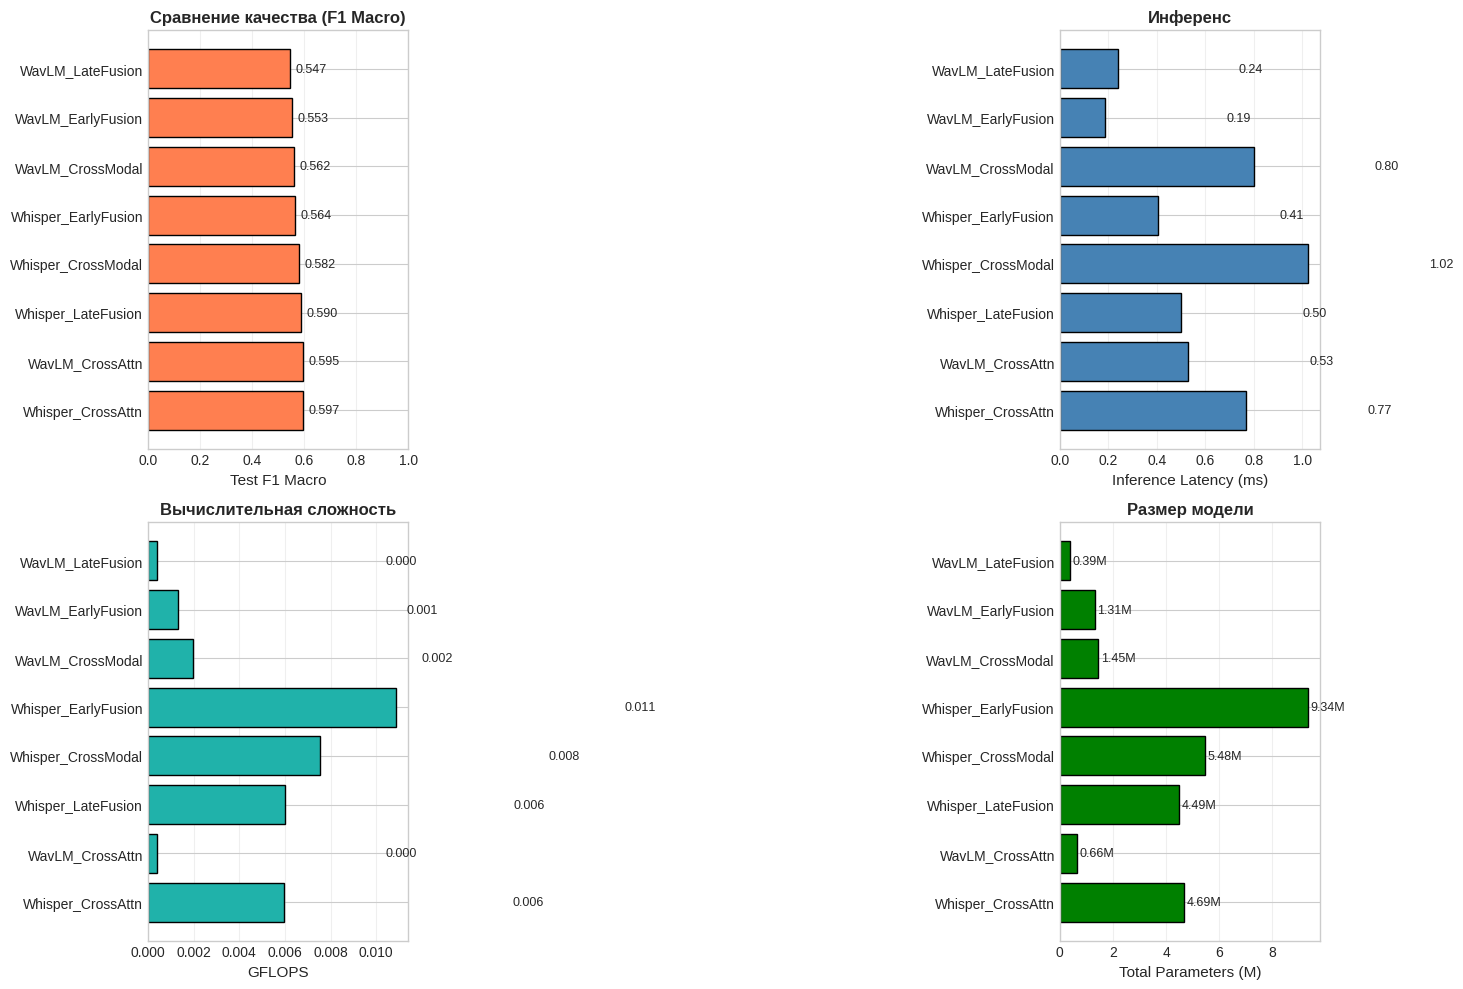

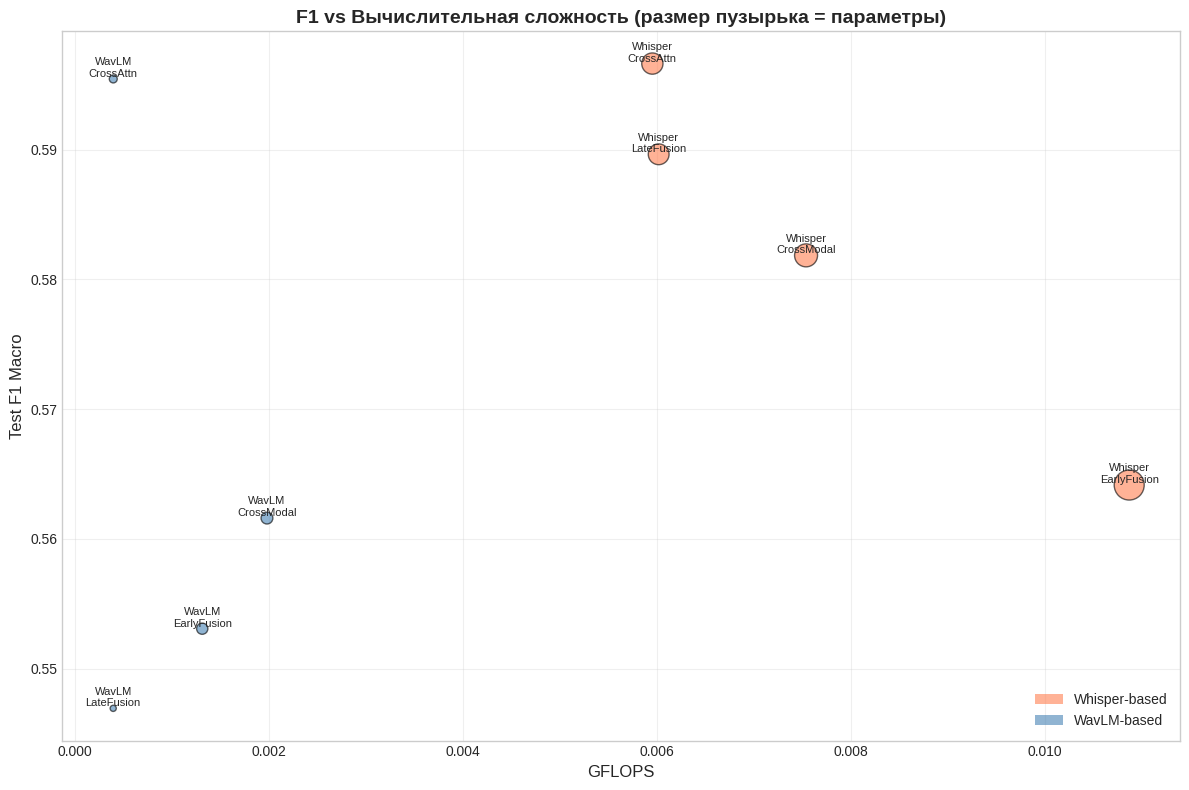

In [186]:
df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("test_f1", ascending=False).reset_index(drop=True)

cols = ["model_name", "test_acc", "test_f1", "best_val_f1", "total_params_millions", "gflops", "model_latency_ms", "e2e_latency_ms", "peak_memory_mb"]

print(df_results[cols].round(4).to_string(index=False))

df_results.to_csv("hybrid_pipeline_results.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. F1 Score
ax = axes[0, 0]
bars = ax.barh(df_results['model_name'], df_results['test_f1'], color='coral', edgecolor='black')
ax.set_xlabel('Test F1 Macro', fontsize=11)
ax.set_title('Сравнение качества (F1 Macro)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['test_f1']):
    ax.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

# 2. Latency
ax = axes[0, 1]
bars = ax.barh(df_results['model_name'], df_results['model_latency_ms'], color='steelblue', edgecolor='black')
ax.set_xlabel('Inference Latency (ms)', fontsize=11)
ax.set_title('Инференс', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['model_latency_ms']):
    ax.text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=9)

# 3. GFLOPS
ax = axes[1, 0]
bars = ax.barh(df_results['model_name'], df_results['gflops'], color='lightseagreen', edgecolor='black')
ax.set_xlabel('GFLOPS', fontsize=11)
ax.set_title('Вычислительная сложность', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['gflops']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# 4. Parameters
ax = axes[1, 1]
bars = ax.barh(df_results['model_name'], df_results['total_params_millions'], color='green', edgecolor='black')
ax.set_xlabel('Total Parameters (M)', fontsize=11)
ax.set_title('Размер модели', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(df_results['total_params_millions']):
    ax.text(v + 0.1, i, f'{v:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("hybrid_pipeline_results.png", dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(12, 8))

colors = []
for name in df_results['model_name']:
    if 'Whisper' in name:
        colors.append('coral')
    else:
        colors.append('steelblue')

scatter = ax2.scatter(df_results['gflops'], df_results['test_f1'], 
                      s=df_results['total_params_millions']*50, 
                      c=colors, alpha=0.6, edgecolors='black', linewidth=1)

for i, row in df_results.iterrows():
    ax2.annotate(row['model_name'].replace('_', '\n'), 
                 (row['gflops'], row['test_f1']),
                 fontsize=8, ha='center', va='bottom')

ax2.set_xlabel('GFLOPS', fontsize=12)
ax2.set_ylabel('Test F1 Macro', fontsize=12)
ax2.set_title('F1 vs Вычислительная сложность (размер пузырька = параметры)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral', alpha=0.6, label='Whisper-based'),
    Patch(facecolor='steelblue', alpha=0.6, label='WavLM-based')
]
ax2.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig("hybrid_pipeline_f1_vs_gflops.png", dpi=150, bbox_inches='tight')
plt.show()